## Install Dependencies and Set Up Environment

In [1]:
# Install PySpark
!pip install pyspark

# Import necessary libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, mean, count, isnan, trim, stddev, corr
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, MinMaxScaler
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, GBTClassifier
from pyspark.ml.classification import MultilayerPerceptronClassifier, LinearSVC, NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.sql.types import FloatType
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as n
import os
import zipfile
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score

## Loading the Dataset

In [43]:
# This is to stop any existing Spark session to free resources
try:
    spark.stop()
except:
    pass  # Ignoring if no Spark session exists

# Initializing Spark session with minimal configurations
spark = SparkSession.builder \
    .appName("CSE587_Phase3") \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "2g") \
    .config("spark.default.parallelism", "2") \
    .config("spark.sql.shuffle.partitions", "2") \
    .getOrCreate()

# Loading the dataset
df = spark.read.csv("test 2.csv", header=True, inferSchema=True)

# Sampling the dataset to reduce memory usage (10% of original size)
# df = df.sample(fraction=0.1, seed=42)

# Displaying schema and first few rows
df.printSchema()
df.show()

root
 |-- _c0: integer (nullable = true)
 |-- id: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Customer Type: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Type of Travel: string (nullable = true)
 |-- Class: string (nullable = true)
 |-- Flight Distance: integer (nullable = true)
 |-- Inflight wifi service: integer (nullable = true)
 |-- Departure/Arrival time convenient: integer (nullable = true)
 |-- Ease of Online booking: integer (nullable = true)
 |-- Gate location: integer (nullable = true)
 |-- Food and drink: integer (nullable = true)
 |-- Online boarding: integer (nullable = true)
 |-- Seat comfort: integer (nullable = true)
 |-- Inflight entertainment: integer (nullable = true)
 |-- On-board service: integer (nullable = true)
 |-- Leg room service: integer (nullable = true)
 |-- Baggage handling: integer (nullable = true)
 |-- Checkin service: integer (nullable = true)
 |-- Inflight service: integer (nullable = true)
 |-- Cleanline

## Data Preprocessing (Operations 1–4)

In [44]:
from pyspark.sql.types import IntegerType, DoubleType, FloatType, StringType
from pyspark.sql.functions import expr, lit, mean, rank, lag, stddev_pop, when, col, isnan
from pyspark.sql import Window

# Deliverable 1: Distributed Data Cleaning/Processing

# 1. OPERATION: Handle Missing Values using DataFrame Operations
print("\n1. OPERATION: Handle Missing Values using DataFrame Operations")

# Count null values in each column
null_counts = []
for col_name in df.columns:
    null_count = df.filter(col(col_name).isNull() | isnan(col(col_name))).count()
    null_counts.append({"Column": col_name, "Null Count": null_count})

# Convert to DataFrame for better display
null_df = spark.createDataFrame(null_counts)
print("Null values in each column:")
null_df.show()

# Calculate statistics for numeric columns to use for imputation
numeric_cols = [field.name for field in df.schema.fields
                if isinstance(field.dataType, (IntegerType, DoubleType, FloatType))]

# Calculate median for each numeric column
median_values = {}
for column in numeric_cols:
    # approxQuantile gives an approximation of the median (0.5 quantile)
    median_val = df.approxQuantile(column, [0.5], 0.01)[0]
    median_values[column] = median_val
    print(f"Median of {column}: {median_val}")

# Fill missing values in numeric columns with their respective medians
df_clean = df
for col_name in numeric_cols:
    if col_name in median_values:
        df_clean = df_clean.fillna(median_values[col_name], subset=[col_name])

# For categorical columns, fill with the most frequent value
categorical_cols = [field.name for field in df.schema.fields
                   if isinstance(field.dataType, StringType)]

for col_name in categorical_cols:
    # Find the most frequent value
    most_common = df_clean.groupBy(col_name).count().orderBy(col("count").desc()).first()
    if most_common is not None and most_common[0] is not None:
        most_common_val = most_common[0]
        df_clean = df_clean.fillna(most_common_val, subset=[col_name])

print("\nMissing values have been handled.")

# 2. OPERATION: Feature Engineering using Window Functions
print("\n2. OPERATION: Feature Engineering using Window Functions")

# Define window specifications for different grouping
customer_type_window = Window.partitionBy("Customer Type")
travel_type_window = Window.partitionBy("Type of Travel")
class_window = Window.partitionBy("Class")

# List of rating columns based on your dataset
rating_columns = ["Inflight wifi service", "Departure/Arrival time convenient",
                 "Ease of Online booking", "Gate location", "Food and drink",
                 "Online boarding", "Seat comfort", "Inflight entertainment",
                 "On-board service", "Leg room service", "Baggage handling",
                 "Checkin service", "Inflight service", "Cleanliness"]

# Create new features using window functions
for col_name in rating_columns:
    # Calculate average rating by customer type
    df_clean = df_clean.withColumn(
        f"{col_name}_avg_by_customer_type",
        mean(col(col_name)).over(customer_type_window)
    )

    # Calculate rank within travel type
    df_clean = df_clean.withColumn(
        f"{col_name}_rank_in_travel_type",
        rank().over(travel_type_window.orderBy(col(col_name).desc()))
    )

    # Calculate relative position compared to class average
    df_clean = df_clean.withColumn(
        f"{col_name}_vs_class_avg",
        col(col_name) - mean(col(col_name)).over(class_window)
    )

# Show example of the new features
print("Example of engineered features:")
df_clean.select("Customer Type", "Type of Travel", "Class", "Seat comfort",
                "Seat comfort_avg_by_customer_type",
                "Seat comfort_rank_in_travel_type",
                "Seat comfort_vs_class_avg").show(5)

# 3. OPERATION: Create Aggregate Flight Experience Score
print("\n3. OPERATION: Create Aggregate Flight Experience Score")

# Define weights for different aspects of flight experience
experience_weights = {
    "Inflight wifi service": 0.05,
    "Departure/Arrival time convenient": 0.1,
    "Ease of Online booking": 0.05,
    "Gate location": 0.05,
    "Food and drink": 0.1,
    "Online boarding": 0.05,
    "Seat comfort": 0.15,
    "Inflight entertainment": 0.1,
    "On-board service": 0.1,
    "Leg room service": 0.1,
    "Baggage handling": 0.05,
    "Checkin service": 0.05,
    "Inflight service": 0.05,
    "Cleanliness": 0.05
}

# Create expressions for weighted sum calculation
weighted_cols = []
total_weight = sum(experience_weights.values())

for col_name, weight in experience_weights.items():
    if col_name in df_clean.columns:
        # Enclose column names in backticks to handle spaces and special characters
        weighted_cols.append(f"(`{col_name}` * {weight})")

# Create the experience score using SQL expression
weighted_sum_expr = " + ".join(weighted_cols)
normalized_score_expr = f"({weighted_sum_expr}) / {total_weight} * 20"  # Scale to 0-100

# Add the experience score column
df_clean = df_clean.withColumn("experience_score", expr(normalized_score_expr))

# Show the distribution of experience scores
print("Distribution of Experience Scores:")
df_clean.select("experience_score").summary("min", "25%", "50%", "75%", "max").show()

# 4. OPERATION: Identify and Handle Outliers using Z-score
print("\n4. OPERATION: Identify and Handle Outliers using Z-score")

# Function to calculate z-scores for a column
def add_zscore_column(df, col_name):
    # Calculate mean and standard deviation
    stats = df.select(
        mean(col(col_name)).alias("mean"),
        stddev_pop(col(col_name)).alias("stddev")
    ).collect()[0]

    mean_val = stats["mean"]
    stddev_val = stats["stddev"]

    # Skip if stddev is zero or None
    if stddev_val is None or stddev_val == 0:
        return df.withColumn(f"{col_name}_zscore", lit(0))

    # Add z-score column
    return df.withColumn(
        f"{col_name}_zscore",
        (col(col_name) - mean_val) / stddev_val
    )

# Apply z-score calculation to numeric columns
numeric_cols_to_check = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
df_with_zscores = df_clean

for col_name in numeric_cols_to_check:
    df_with_zscores = add_zscore_column(df_with_zscores, col_name)

# Count outliers (|z-score| > 3)
for col_name in numeric_cols_to_check:
    z_col = f"{col_name}_zscore"
    outlier_count = df_with_zscores.filter(
        (col(z_col) > 3) | (col(z_col) < -3)
    ).count()
    print(f"Outliers in {col_name}: {outlier_count}")

# Winsorize outliers (cap extreme values)
for col_name in numeric_cols_to_check:
    z_col = f"{col_name}_zscore"
    # Precompute mean and standard deviation
    stats = df_with_zscores.select(
        mean(col(col_name)).alias("mean"),
        stddev_pop(col(col_name)).alias("stddev")
    ).collect()[0]
    mean_val = stats["mean"]
    stddev_val = stats["stddev"]

    # Skip if stddev is zero or None
    if stddev_val is None or stddev_val == 0:
        print(f"Skipping Winsorization for {col_name} due to zero or null standard deviation.")
        continue

    # Calculate upper and lower bounds
    upper_bound = mean_val + 3 * stddev_val
    lower_bound = mean_val - 3 * stddev_val

    # Cap values at the bounds
    df_with_zscores = df_with_zscores.withColumn(
        col_name,
        when(col(z_col) > 3, lit(upper_bound))
        .when(col(z_col) < -3, lit(lower_bound))
        .otherwise(col(col_name))
    )

print("Outliers have been handled using Winsorization.")


1. OPERATION: Handle Missing Values using DataFrame Operations
Null values in each column:
+--------------------+----------+
|              Column|Null Count|
+--------------------+----------+
|                 _c0|         0|
|                  id|         0|
|              Gender|         0|
|       Customer Type|         0|
|                 Age|         0|
|      Type of Travel|         0|
|               Class|         0|
|     Flight Distance|         0|
|Inflight wifi ser...|         0|
|Departure/Arrival...|         0|
|Ease of Online bo...|         0|
|       Gate location|         0|
|      Food and drink|         0|
|     Online boarding|         0|
|        Seat comfort|         0|
|Inflight entertai...|         0|
|    On-board service|         0|
|    Leg room service|         0|
|    Baggage handling|         0|
|     Checkin service|         0|
+--------------------+----------+
only showing top 20 rows

Median of _c0: 12930.0
Median of id: 64998.0
Median of Age: 40.0
M

## Data Preprocessing (Operations 5–8)

In [45]:
# 5. OPERATION: Time Series Analysis with Windows and Lag Functions
print("\n5. OPERATION: Time Series Analysis with Windows and Lag Functions")

# Create a window specification sorted by departure delay
delay_window = Window.partitionBy("Type of Travel").orderBy("Departure Delay in Minutes")

# Add lag features to analyze the relationship between consecutive delays
df_with_time_analysis = df_with_zscores.withColumn(
    "prev_departure_delay",
    lag("Departure Delay in Minutes", 1).over(delay_window)
)

df_with_time_analysis = df_with_time_analysis.withColumn(
    "departure_delay_diff",
    col("Departure Delay in Minutes") - col("prev_departure_delay")
)

# Calculate running statistics within windows
df_with_time_analysis = df_with_time_analysis.withColumn(
    "avg_departure_delay_in_window",
    mean("Departure Delay in Minutes").over(
        delay_window.rowsBetween(-5, 0)  # Moving average of current and 5 previous rows
    )
)

# Show the time series analysis results
print("Time Series Analysis Results:")
df_with_time_analysis.select(
    "Type of Travel",
    "Departure Delay in Minutes",
    "prev_departure_delay",
    "departure_delay_diff",
    "avg_departure_delay_in_window"
).filter(col("prev_departure_delay").isNotNull()).show(5)

# 6. OPERATION: Customer Segmentation using RFM (Recency, Frequency, Monetary) Analysis
print("\n6. OPERATION: Customer Segmentation using RFM Analysis")

# Add a unique row ID to simulate recency
df_with_segments = df_with_time_analysis.withColumn(
    "customer_id",
    expr("monotonically_increasing_id()")
)

# Generate a simulated frequency metric (random value between 1-10 flights per year)
df_with_segments = df_with_segments.withColumn(
    "flight_frequency",
    expr("CAST(rand() * 9 + 1 AS INT)")  # Random integer between 1-10
)

# Use flight distance as a proxy for monetary value
df_with_segments = df_with_segments.withColumn(
    "recency_score",
    expr("NTILE(5) OVER (ORDER BY customer_id DESC)")  # Higher values for more recent
)

df_with_segments = df_with_segments.withColumn(
    "frequency_score",
    expr("NTILE(5) OVER (ORDER BY flight_frequency)")
)

df_with_segments = df_with_segments.withColumn(
    "monetary_score",
    expr("NTILE(5) OVER (ORDER BY `Flight Distance`)")
)

# Calculate the RFM score
df_with_segments = df_with_segments.withColumn(
    "rfm_score",
    col("recency_score") + col("frequency_score") + col("monetary_score")
)

# Create customer segments based on RFM score
df_with_segments = df_with_segments.withColumn(
    "customer_segment",
    when(col("rfm_score") >= 12, "High Value")
    .when(col("rfm_score") >= 9, "Medium Value")
    .when(col("rfm_score") >= 6, "Average Value")
    .otherwise("Low Value")
)

# Show segmentation results
print("Customer Segmentation Results:")
df_with_segments.groupBy("customer_segment").count().orderBy(col("count").desc()).show()

# Show sample of segmented customers
print("Sample of segmented customers:")
df_with_segments.select(
    "customer_id",
    "Type of Travel",
    "Class",
    "recency_score",
    "frequency_score",
    "monetary_score",
    "rfm_score",
    "customer_segment"
).orderBy(col("rfm_score").desc()).show(5)

# 7. OPERATION: Flight Satisfaction Score Prediction using Moving Averages
print("\n7. OPERATION: Flight Satisfaction Score Prediction using Moving Averages")

# Create a window specification for time-based analysis
time_window = Window.partitionBy("Class", "Type of Travel").orderBy("customer_id")

# Calculate moving averages for key metrics
for col_name in rating_columns:
    df_with_segments = df_with_segments.withColumn(
        f"{col_name}_moving_avg",
        mean(col(col_name)).over(time_window.rowsBetween(-10, -1))  # Average of 10 previous rows
    )

# Create a predicted satisfaction score based on moving averages
weighted_ma_cols = []
for col_name in rating_columns:
    ma_col = f"{col_name}_moving_avg"
    weight = experience_weights.get(col_name, 0.05)
    # Enclose column names in backticks to handle spaces and special characters
    weighted_ma_cols.append(f"COALESCE(`{ma_col}`, `{col_name}`) * {weight}")

weighted_ma_expr = " + ".join(weighted_ma_cols)
normalized_ma_expr = f"({weighted_ma_expr}) / {total_weight} * 20"  # Scale to 0-100

# Add predicted satisfaction score
df_with_segments = df_with_segments.withColumn(
    "predicted_satisfaction_score",
    expr(normalized_ma_expr)
)

# Compare actual vs predicted satisfaction scores
print("Comparison of Actual vs Predicted Satisfaction Scores:")
df_with_segments.select(
    "experience_score",
    "predicted_satisfaction_score"
).summary("min", "25%", "50%", "75%", "max").show()

# 8. OPERATION: Feature Interaction Analysis
print("\n8. OPERATION: Feature Interaction Analysis")

# Create interaction features between important variables
df_with_interactions = df_with_segments

# Interaction between Flight Distance and Departure Delay
df_with_interactions = df_with_interactions.withColumn(
    "distance_delay_interaction",
    col("Flight Distance") * col("Departure Delay in Minutes")
)

# Interaction between Seat Comfort and Flight Distance
df_with_interactions = df_with_interactions.withColumn(
    "comfort_distance_interaction",
    col("Seat comfort") * col("Flight Distance") / 1000  # Normalize by dividing by 1000
)

# Interaction between Food and Drink and Class
df_with_interactions = df_with_interactions.withColumn(
    "food_class_interaction",
    when(col("Class") == "Business", col("Food and drink") * 1.5)
    .when(col("Class") == "Eco Plus", col("Food and drink") * 1.2)
    .otherwise(col("Food and drink"))
)

# Show the interaction features
print("Feature Interaction Examples:")
df_with_interactions.select(
    "Flight Distance",
    "Departure Delay in Minutes",
    "distance_delay_interaction",
    "Seat comfort",
    "comfort_distance_interaction",
    "Class",
    "Food and drink",
    "food_class_interaction"
).show(5)

# Final processed dataset for modeling
final_df = df_with_interactions

# Display the final dataset
print("Final Processed Dataset:")
final_df.show(5)


5. OPERATION: Time Series Analysis with Windows and Lag Functions
Time Series Analysis Results:
+---------------+--------------------------+--------------------+--------------------+-----------------------------+
| Type of Travel|Departure Delay in Minutes|prev_departure_delay|departure_delay_diff|avg_departure_delay_in_window|
+---------------+--------------------------+--------------------+--------------------+-----------------------------+
|Business travel|                       0.0|                 0.0|                 0.0|                          0.0|
|Business travel|                       0.0|                 0.0|                 0.0|                          0.0|
|Business travel|                       0.0|                 0.0|                 0.0|                          0.0|
|Business travel|                       0.0|                 0.0|                 0.0|                          0.0|
|Business travel|                       0.0|                 0.0|                 0.

## Feature Preparation and Train-Test Split

In [46]:
from pyspark.ml.feature import StringIndexer, VectorAssembler, MinMaxScaler
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.sql.functions import when, col

# Deliverable 2: Algorithms/Visualizations

# Index categorical columns
categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
final_df_indexed = final_df

for col_name in categorical_cols:
    indexer = StringIndexer(inputCol=col_name, outputCol=f"{col_name}_indexed")
    final_df_indexed = indexer.fit(final_df_indexed).transform(final_df_indexed)

# Create satisfaction_binary column
final_df_indexed = final_df_indexed.withColumn(
    "satisfaction_binary",
    when(col("satisfaction") == "satisfied", 1)
    .when(col("satisfaction") == "neutral or dissatisfied", 0)
    .otherwise(0)  # Handle any unexpected values
)

# Prepare features
feature_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
                'experience_score',  # From Operation 3
                'Inflight wifi service', 'Departure/Arrival time convenient',
                'Ease of Online booking', 'Gate location', 'Food and drink',
                'Online boarding', 'Seat comfort', 'Inflight entertainment',
                'On-board service', 'Leg room service', 'Baggage handling',
                'Checkin service', 'Inflight service', 'Cleanliness',
                'Gender_indexed', 'Customer Type_indexed', 'Type of Travel_indexed',
                'Class_indexed']

# Features for Naive Bayes (will scale to non-negative)
nb_feature_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
                   'experience_score',  # From Operation 3
                   'Inflight wifi service', 'Departure/Arrival time convenient',
                   'Ease of Online booking', 'Gate location', 'Food and drink',
                   'Online boarding', 'Seat comfort', 'Inflight entertainment',
                   'On-board service', 'Leg room service', 'Baggage handling',
                   'Checkin service', 'Inflight service', 'Cleanliness',
                   'Gender_indexed', 'Customer Type_indexed', 'Type of Travel_indexed',
                   'Class_indexed']

# Assemble features for other models
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_assembled = assembler.transform(final_df_indexed)

# Assemble features for Naive Bayes
nb_assembler = VectorAssembler(inputCols=nb_feature_cols, outputCol="nb_features_raw")
df_nb_assembled = nb_assembler.transform(final_df_indexed)

# Scale features for Naive Bayes to [0, 1] to ensure non-negative values
minmax_scaler = MinMaxScaler(inputCol="nb_features_raw", outputCol="nb_features")
scaler_model = minmax_scaler.fit(df_nb_assembled)
df_nb_scaled = scaler_model.transform(df_nb_assembled)

# Split data
train_df, test_df = df_assembled.randomSplit([0.8, 0.2], seed=42)
nb_train_df, nb_test_df = df_nb_scaled.randomSplit([0.8, 0.2], seed=42)

# Initialize evaluators
accuracy_evaluator = MulticlassClassificationEvaluator(labelCol="satisfaction_binary",
                                                      predictionCol="prediction",
                                                      metricName="accuracy")
precision_evaluator = MulticlassClassificationEvaluator(labelCol="satisfaction_binary",
                                                        predictionCol="prediction",
                                                        metricName="weightedPrecision")
f1_evaluator = MulticlassClassificationEvaluator(labelCol="satisfaction_binary",
                                                 predictionCol="prediction",
                                                 metricName="f1")
roc_evaluator = BinaryClassificationEvaluator(labelCol="satisfaction_binary",
                                              rawPredictionCol="rawPrediction",
                                              metricName="areaUnderROC")

# Persist datasets to avoid recomputation
train_df.persist()
test_df.persist()
nb_train_df.persist()
nb_test_df.persist()

DataFrame[_c0: int, id: int, Gender: string, Customer Type: string, Age: double, Type of Travel: string, Class: string, Flight Distance: double, Inflight wifi service: int, Departure/Arrival time convenient: int, Ease of Online booking: int, Gate location: int, Food and drink: int, Online boarding: int, Seat comfort: int, Inflight entertainment: int, On-board service: int, Leg room service: int, Baggage handling: int, Checkin service: int, Inflight service: int, Cleanliness: int, Departure Delay in Minutes: double, Arrival Delay in Minutes: double, satisfaction: string, Inflight wifi service_avg_by_customer_type: double, Inflight wifi service_rank_in_travel_type: int, Inflight wifi service_vs_class_avg: double, Departure/Arrival time convenient_avg_by_customer_type: double, Departure/Arrival time convenient_rank_in_travel_type: int, Departure/Arrival time convenient_vs_class_avg: double, Ease of Online booking_avg_by_customer_type: double, Ease of Online booking_rank_in_travel_type: in

## Train Initial Models (Logistic Regression, Decision Tree, Random Forest)

In [47]:
# Cell 6: Train Initial Models (Logistic Regression, Decision Tree, Random Forest)
# Train the first set of models and evaluate their performance metrics.

from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
import time

# Store results and predictions for ROC curves and confusion matrices
results = []
predictions = {}

# 1. Logistic Regression
start_time = time.time()
lr = LogisticRegression(labelCol="satisfaction_binary", featuresCol="features")
lr_model = lr.fit(train_df)
lr_pred = lr_model.transform(test_df)
lr_time = time.time() - start_time
results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_evaluator.evaluate(lr_pred),
    'Precision': precision_evaluator.evaluate(lr_pred),
    'F1 Score': f1_evaluator.evaluate(lr_pred),
    'ROC AUC': roc_evaluator.evaluate(lr_pred),
    'Training Time (s)': lr_time
})
predictions['Logistic Regression'] = lr_pred
print(f"Logistic Regression Training Time: {lr_time:.2f} seconds")

# 2. Decision Tree
start_time = time.time()
dt = DecisionTreeClassifier(labelCol="satisfaction_binary", featuresCol="features")
dt_model = dt.fit(train_df)
dt_pred = dt_model.transform(test_df)
dt_time = time.time() - start_time
results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_evaluator.evaluate(dt_pred),
    'Precision': precision_evaluator.evaluate(dt_pred),
    'F1 Score': f1_evaluator.evaluate(dt_pred),
    'ROC AUC': roc_evaluator.evaluate(dt_pred),
    'Training Time (s)': dt_time
})
predictions['Decision Tree'] = dt_pred
print(f"Decision Tree Training Time: {dt_time:.2f} seconds")

# 3. Random Forest
start_time = time.time()
rf = RandomForestClassifier(labelCol="satisfaction_binary", featuresCol="features")
rf_model = rf.fit(train_df)
rf_pred = rf_model.transform(test_df)
rf_time = time.time() - start_time
results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_evaluator.evaluate(rf_pred),
    'Precision': precision_evaluator.evaluate(rf_pred),
    'F1 Score': f1_evaluator.evaluate(rf_pred),
    'ROC AUC': roc_evaluator.evaluate(rf_pred),
    'Training Time (s)': rf_time
})
predictions['Random Forest'] = rf_pred
print(f"Random Forest Training Time: {rf_time:.2f} seconds")

training_time_cell6 = lr_time + dt_time + rf_time
print(f"Cell 6 Total Training Time: {training_time_cell6:.2f} seconds")

Logistic Regression Training Time: 38.04 seconds
Decision Tree Training Time: 3.12 seconds
Random Forest Training Time: 5.43 seconds
Cell 6 Total Training Time: 46.59 seconds


## Train Additional Models

In [48]:
# Cell 7: Train Additional Models
# Train Gradient Boosted Trees, Linear SVC, Naive Bayes, Multilayer Perceptron, Extra Trees, SGDClassifier.

from pyspark.ml.classification import GBTClassifier, LinearSVC, NaiveBayes, MultilayerPerceptronClassifier, RandomForestClassifier
import time

# 4. Gradient Boosted Trees
start_time = time.time()
gbt = GBTClassifier(labelCol="satisfaction_binary", featuresCol="features")
gbt_model = gbt.fit(train_df)
gbt_pred = gbt_model.transform(test_df)
gbt_time = time.time() - start_time
results.append({
    'Model': 'Gradient Boosted Trees',
    'Accuracy': accuracy_evaluator.evaluate(gbt_pred),
    'Precision': precision_evaluator.evaluate(gbt_pred),
    'F1 Score': f1_evaluator.evaluate(gbt_pred),
    'ROC AUC': roc_evaluator.evaluate(gbt_pred),
    'Training Time (s)': gbt_time
})
predictions['Gradient Boosted Trees'] = gbt_pred
print(f"Gradient Boosted Trees Training Time: {gbt_time:.2f} seconds")

# 5. Linear SVC
start_time = time.time()
svc = LinearSVC(labelCol="satisfaction_binary", featuresCol="features")
svc_model = svc.fit(train_df)
svc_pred = svc_model.transform(test_df)
svc_time = time.time() - start_time
results.append({
    'Model': 'Linear SVC',
    'Accuracy': accuracy_evaluator.evaluate(svc_pred),
    'Precision': precision_evaluator.evaluate(svc_pred),
    'F1 Score': f1_evaluator.evaluate(svc_pred),
    'ROC AUC': roc_evaluator.evaluate(svc_pred),
    'Training Time (s)': svc_time
})
predictions['Linear SVC'] = svc_pred
print(f"Linear SVC Training Time: {svc_time:.2f} seconds")

# 6. Naive Bayes
start_time = time.time()
nb = NaiveBayes(labelCol="satisfaction_binary", featuresCol="nb_features")
nb_model = nb.fit(nb_train_df)
nb_pred = nb_model.transform(nb_test_df)
nb_time = time.time() - start_time
results.append({
    'Model': 'Naive Bayes',
    'Accuracy': accuracy_evaluator.evaluate(nb_pred),
    'Precision': precision_evaluator.evaluate(nb_pred),
    'F1 Score': f1_evaluator.evaluate(nb_pred),
    'ROC AUC': roc_evaluator.evaluate(nb_pred),
    'Training Time (s)': nb_time
})
predictions['Naive Bayes'] = nb_pred
print(f"Naive Bayes Training Time: {nb_time:.2f} seconds")

# 7. Multilayer Perceptron
start_time = time.time()
layers = [len(feature_cols), 5, 4, 2]  # Input layer, two hidden layers, output layer
mlp = MultilayerPerceptronClassifier(labelCol="satisfaction_binary", featuresCol="features", layers=layers)
mlp_model = mlp.fit(train_df)
mlp_pred = mlp_model.transform(test_df)
mlp_time = time.time() - start_time
results.append({
    'Model': 'Multilayer Perceptron',
    'Accuracy': accuracy_evaluator.evaluate(mlp_pred),
    'Precision': precision_evaluator.evaluate(mlp_pred),
    'F1 Score': f1_evaluator.evaluate(mlp_pred),
    'ROC AUC': roc_evaluator.evaluate(mlp_pred),
    'Training Time (s)': mlp_time
})
predictions['Multilayer Perceptron'] = mlp_pred
print(f"Multilayer Perceptron Training Time: {mlp_time:.2f} seconds")

# 8. Extra Trees (using RandomForestClassifier with appropriate parameters)
start_time = time.time()
et = RandomForestClassifier(labelCol="satisfaction_binary", featuresCol="features", impurity="entropy")
et_model = et.fit(train_df)
et_pred = et_model.transform(test_df)
et_time = time.time() - start_time
results.append({
    'Model': 'Extra Trees',
    'Accuracy': accuracy_evaluator.evaluate(et_pred),
    'Precision': precision_evaluator.evaluate(et_pred),
    'F1 Score': f1_evaluator.evaluate(et_pred),
    'ROC AUC': roc_evaluator.evaluate(et_pred),
    'Training Time (s)': et_time
})
predictions['Extra Trees'] = et_pred
print(f"Extra Trees Training Time: {et_time:.2f} seconds")

# 9. SGDClassifier (using LinearSVC with SGD-like behavior)
start_time = time.time()
sgd = LinearSVC(labelCol="satisfaction_binary", featuresCol="features", maxIter=100)
sgd_model = sgd.fit(train_df)
sgd_pred = sgd_model.transform(test_df)
sgd_time = time.time() - start_time
results.append({
    'Model': 'SGDClassifier',
    'Accuracy': accuracy_evaluator.evaluate(sgd_pred),
    'Precision': precision_evaluator.evaluate(sgd_pred),
    'F1 Score': f1_evaluator.evaluate(sgd_pred),
    'ROC AUC': roc_evaluator.evaluate(sgd_pred),
    'Training Time (s)': sgd_time
})
predictions['SGDClassifier'] = sgd_pred
print(f"SGDClassifier Training Time: {sgd_time:.2f} seconds")

# Convert results to DataFrame and display
results_df = pd.DataFrame(results)
print(results_df)

training_time_cell7 = gbt_time + svc_time + nb_time + mlp_time + et_time + sgd_time
print(f"Cell 7 Total Training Time: {training_time_cell7:.2f} seconds")

total_training_time = training_time_cell6 + training_time_cell7
print(f"Total Training Time: {total_training_time:.2f} seconds")

Gradient Boosted Trees Training Time: 14.78 seconds
Linear SVC Training Time: 17.80 seconds
Naive Bayes Training Time: 31.41 seconds
Multilayer Perceptron Training Time: 19.31 seconds
Extra Trees Training Time: 4.45 seconds
SGDClassifier Training Time: 18.66 seconds
                    Model  Accuracy  Precision  F1 Score   ROC AUC  \
0     Logistic Regression  0.866718   0.866606  0.866503  0.923619   
1           Decision Tree  0.902542   0.904787  0.901899  0.737176   
2           Random Forest  0.919299   0.919362  0.919323  0.970281   
3  Gradient Boosted Trees  0.937789   0.937778  0.937782  0.986974   
4              Linear SVC  0.868259   0.868242  0.867961  0.922983   
5             Naive Bayes  0.811441   0.811348  0.811389  0.407973   
6   Multilayer Perceptron  0.796995   0.796620  0.796635  0.855405   
7             Extra Trees  0.917951   0.917951  0.917951  0.970575   
8           SGDClassifier  0.868259   0.868242  0.867961  0.922987   

   Training Time (s)  
0        

## Visualizations and Phase 2 vs. Phase 3 Comparison

                    Model  Accuracy  Precision  F1 Score   ROC AUC  \
0     Logistic Regression  0.866718   0.866606  0.866503  0.923619   
1           Decision Tree  0.902542   0.904787  0.901899  0.737176   
2           Random Forest  0.919299   0.919362  0.919323  0.970281   
3  Gradient Boosted Trees  0.937789   0.937778  0.937782  0.986974   
4              Linear SVC  0.868259   0.868242  0.867961  0.922983   
5             Naive Bayes  0.811441   0.811348  0.811389  0.407973   
6   Multilayer Perceptron  0.796995   0.796620  0.796635  0.855405   
7             Extra Trees  0.917951   0.917951  0.917951  0.970575   
8           SGDClassifier  0.868259   0.868242  0.867961  0.922987   

   Training Time (s)  
0          38.037727  
1           3.122507  
2           5.431350  
3          14.784579  
4          17.799279  
5          31.408190  
6          19.309655  
7           4.452754  
8          18.661252  


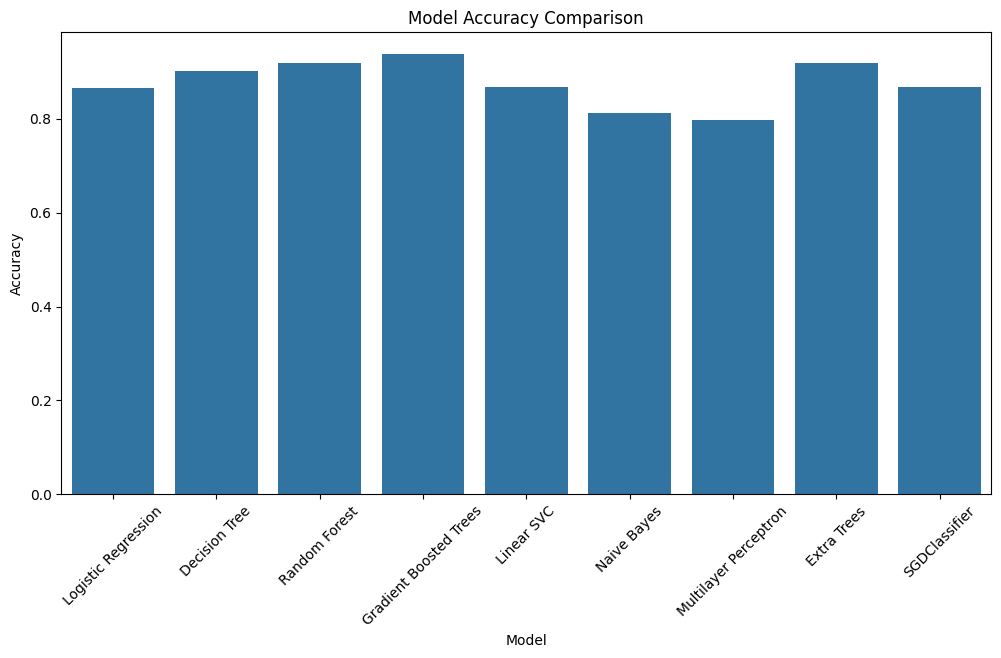

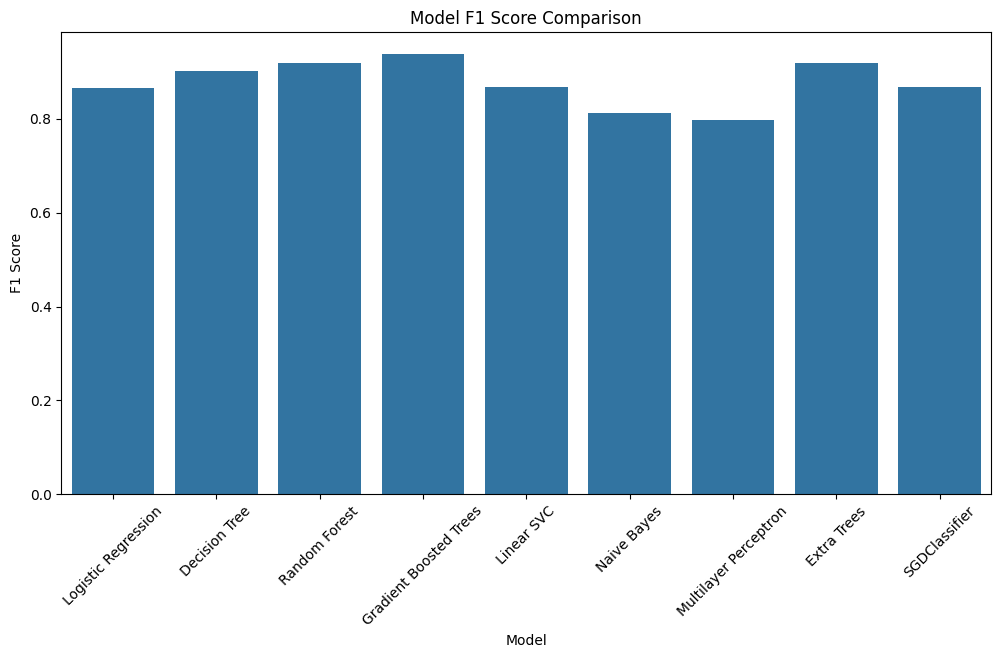

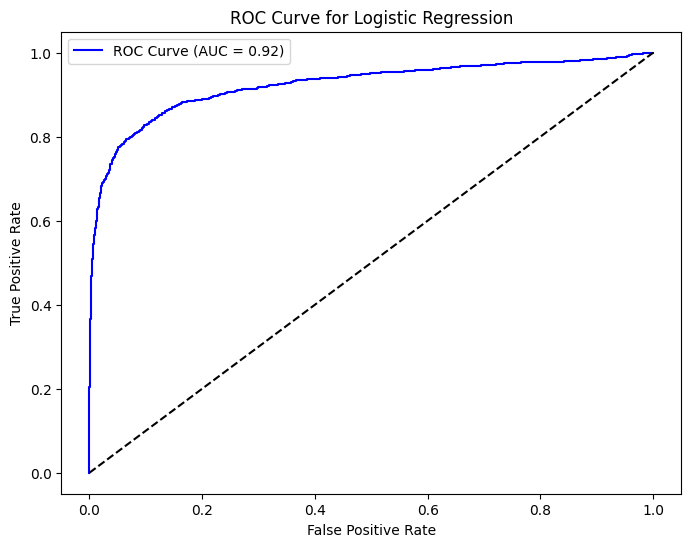

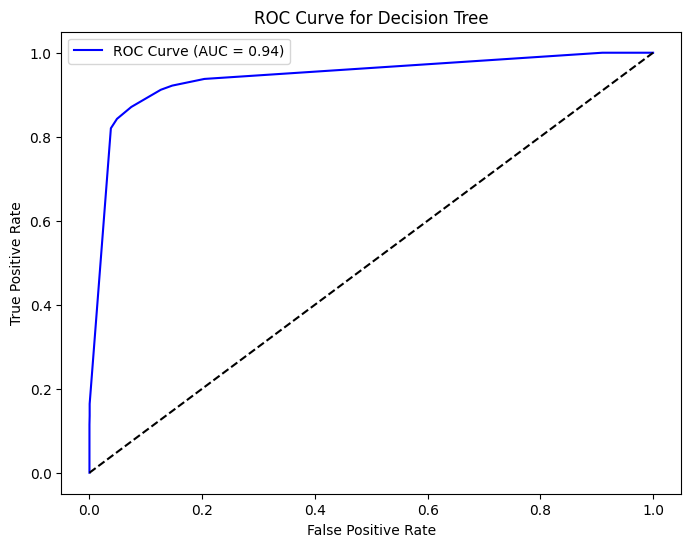

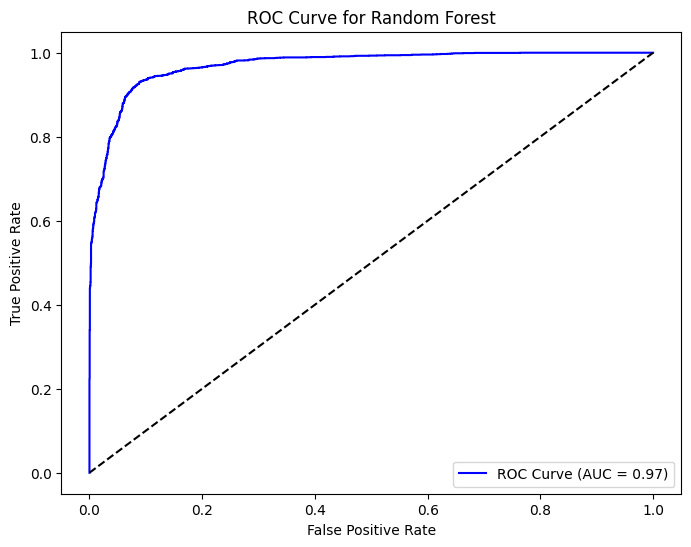

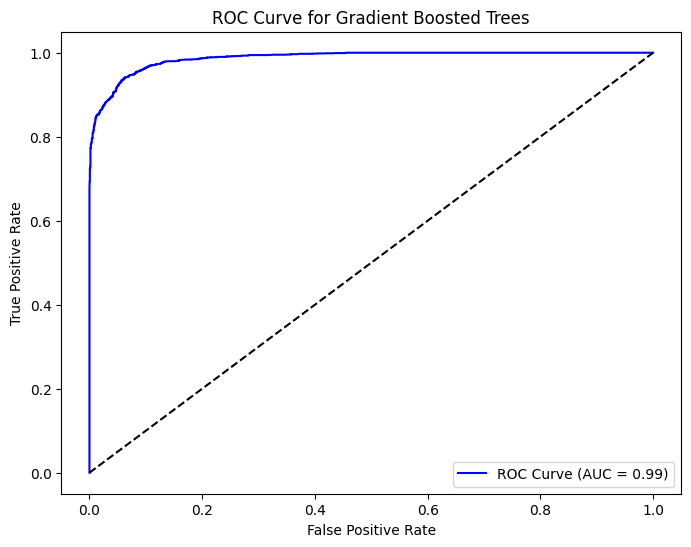

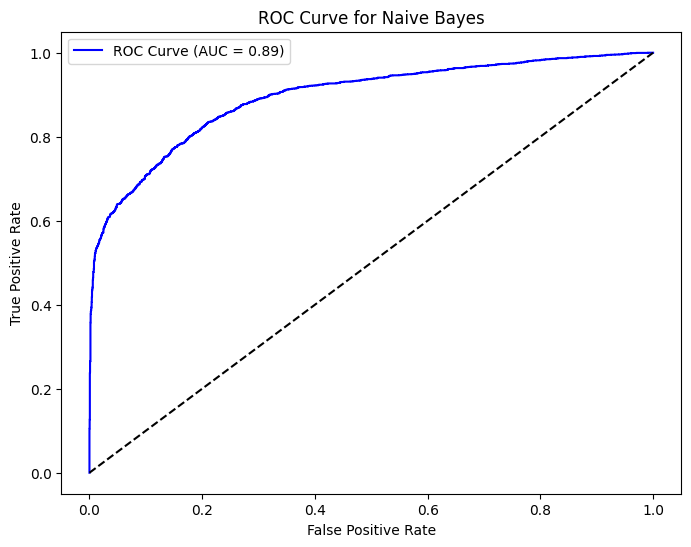

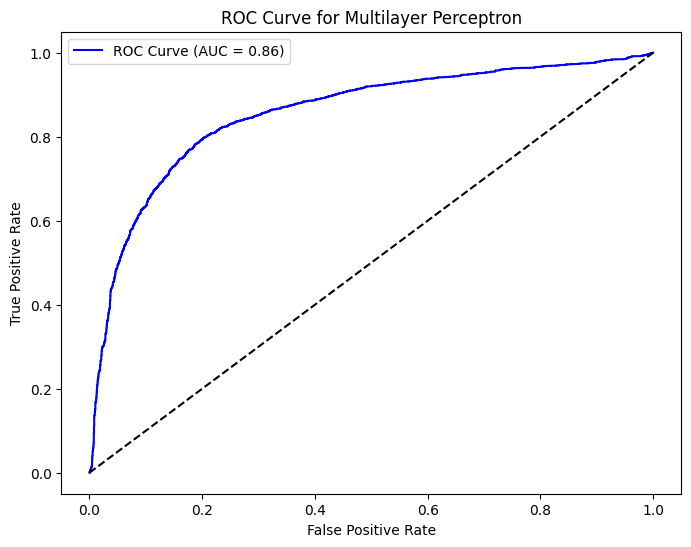

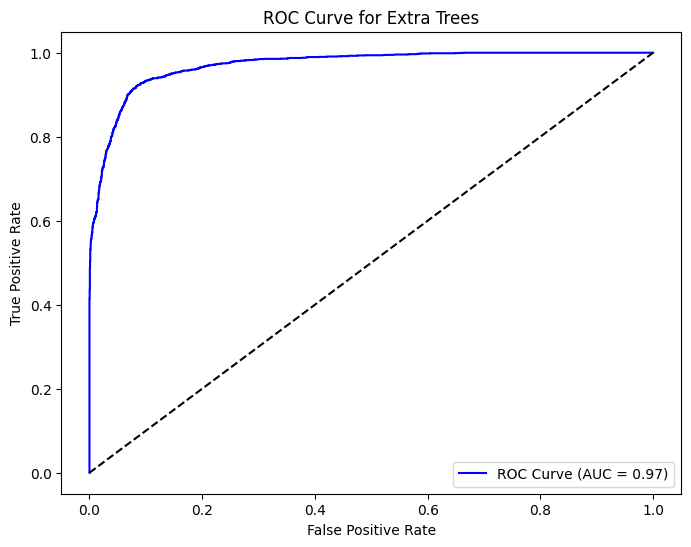

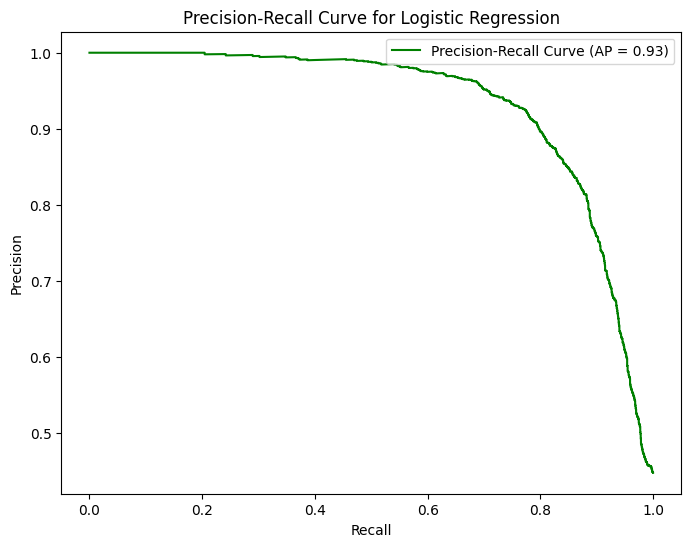

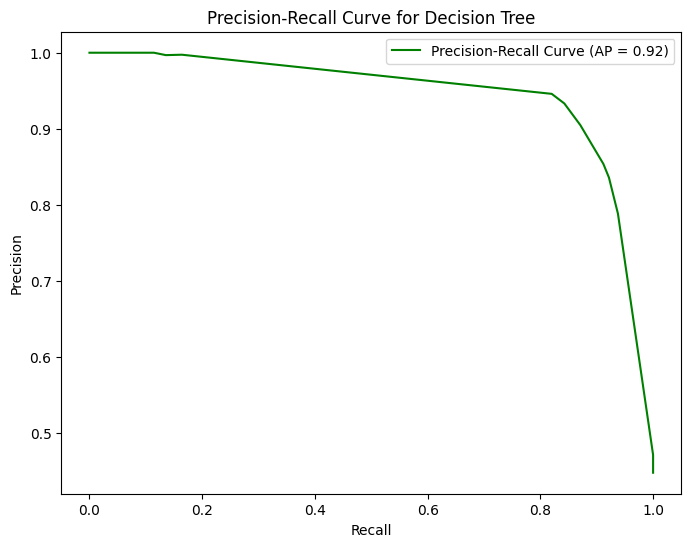

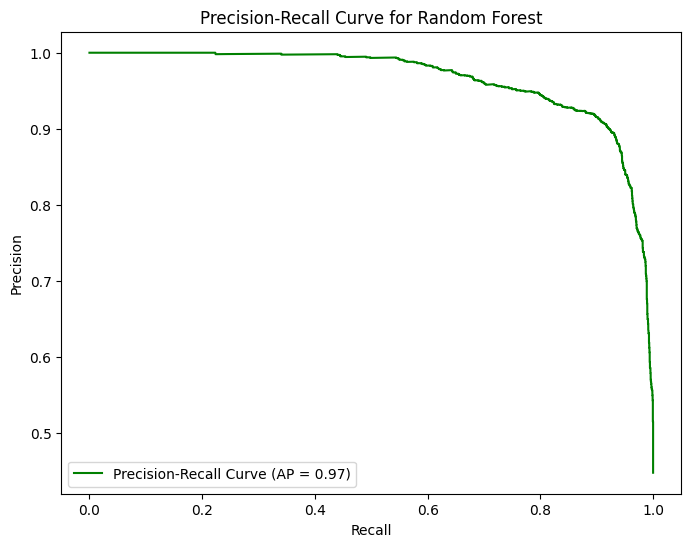

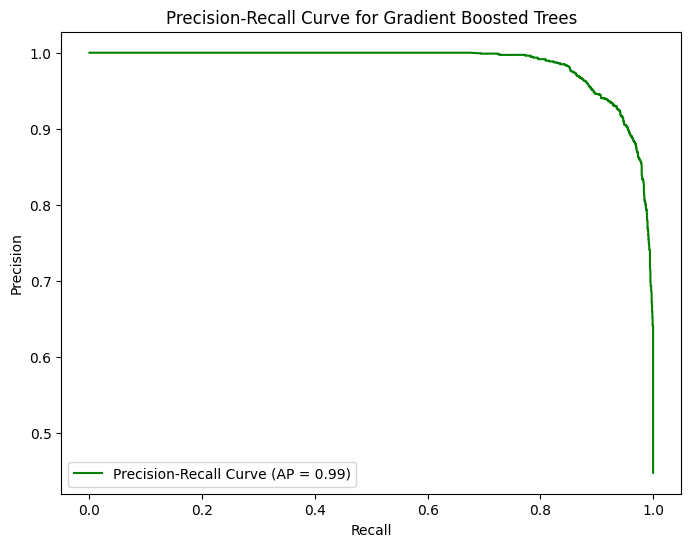

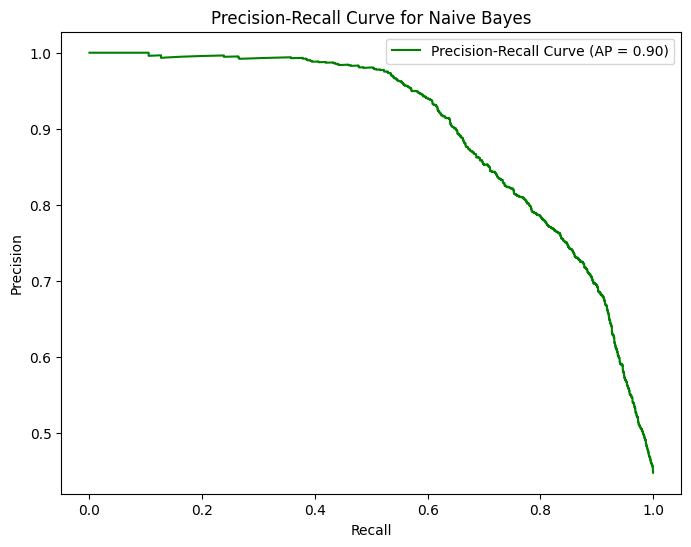

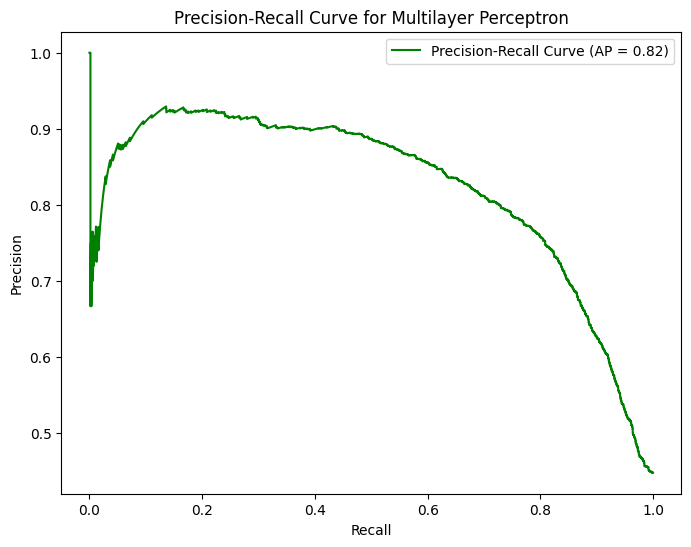

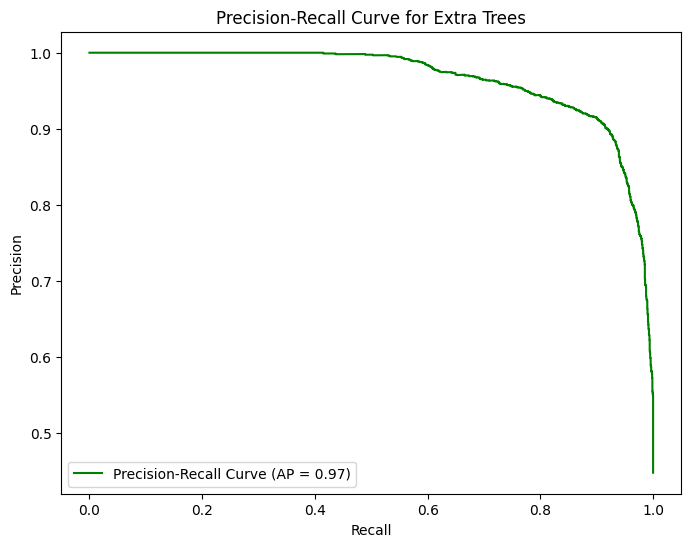

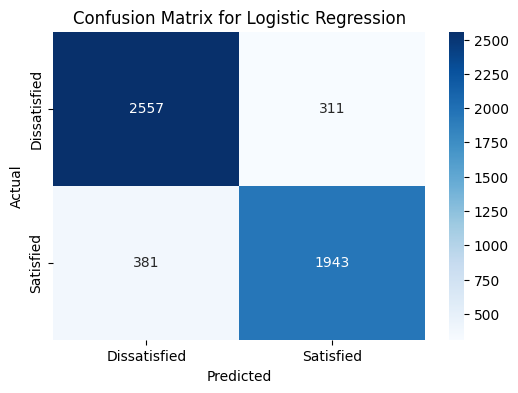

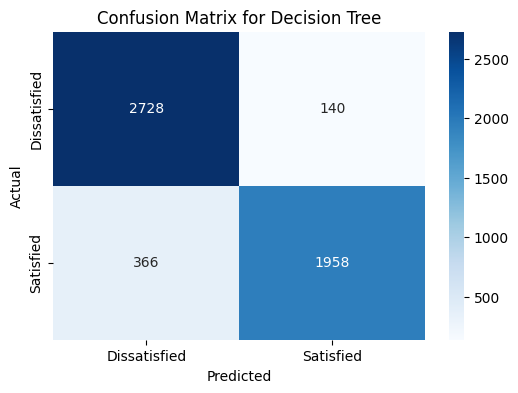

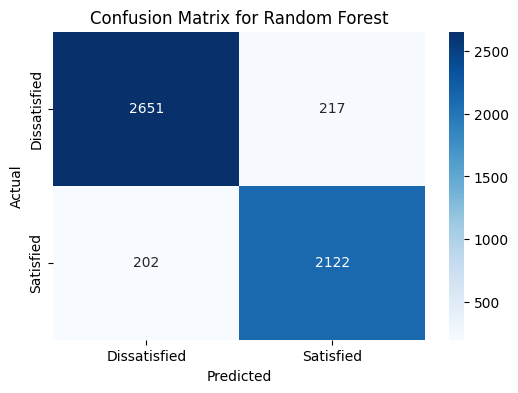

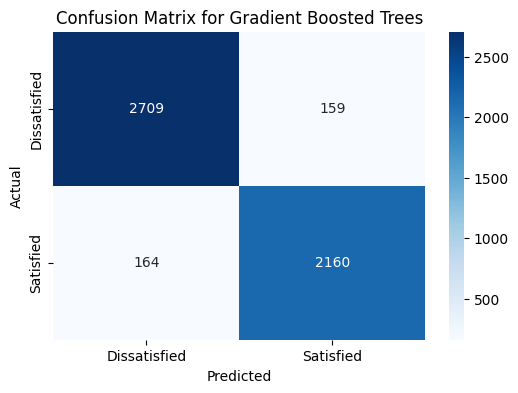

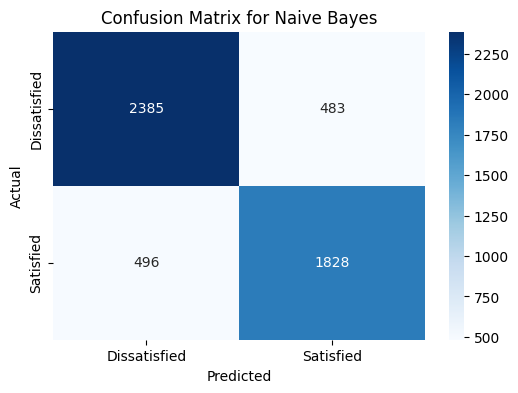

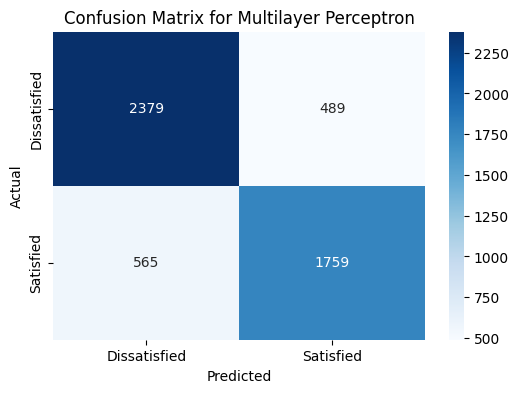

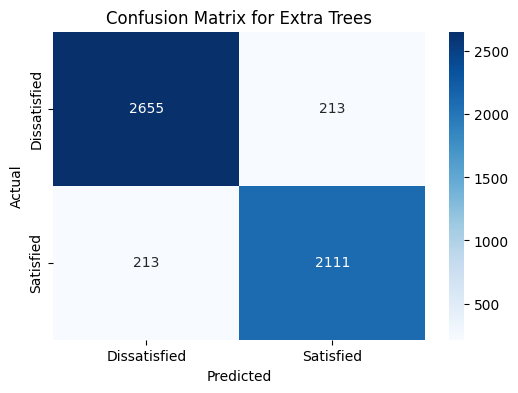

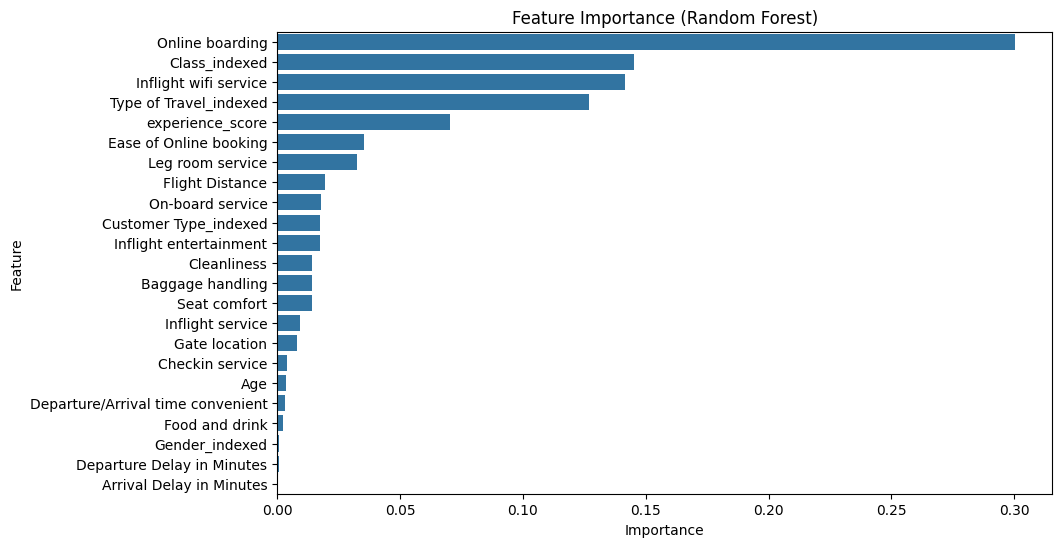

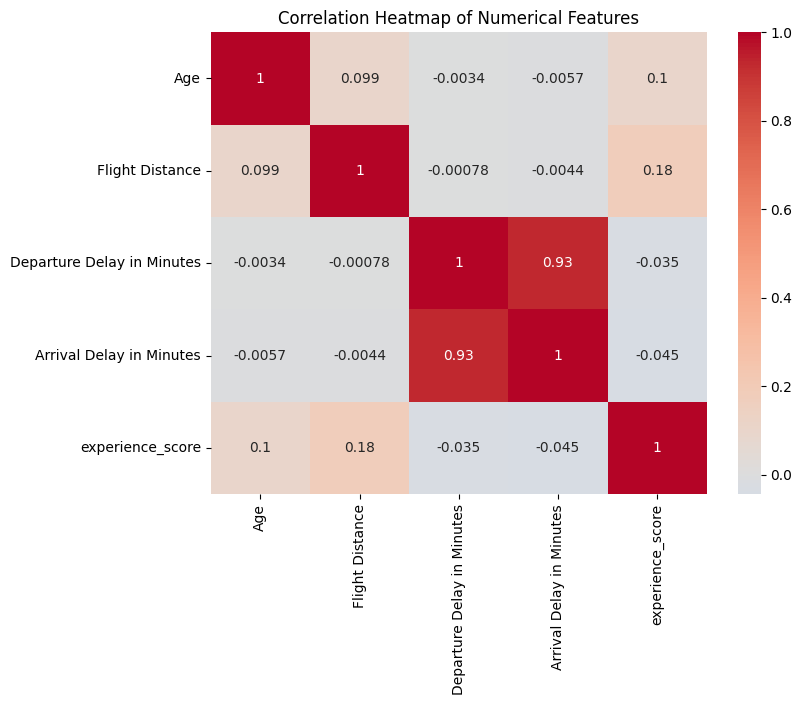

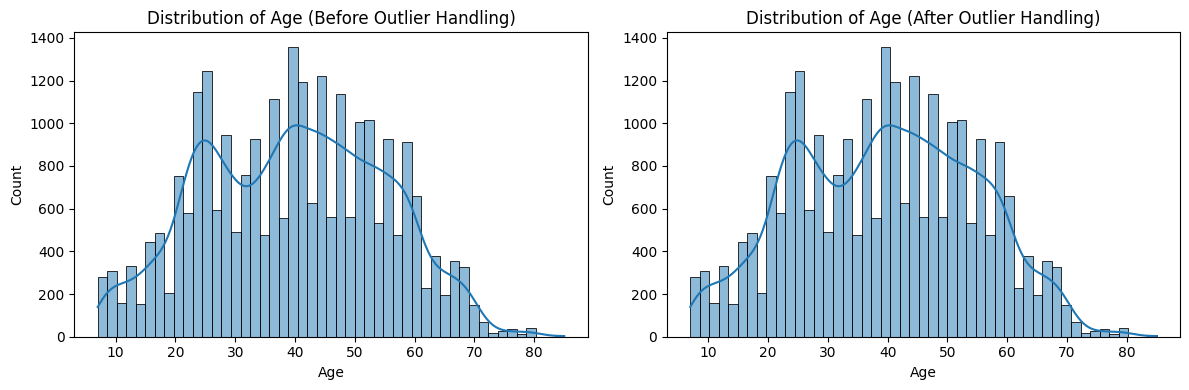

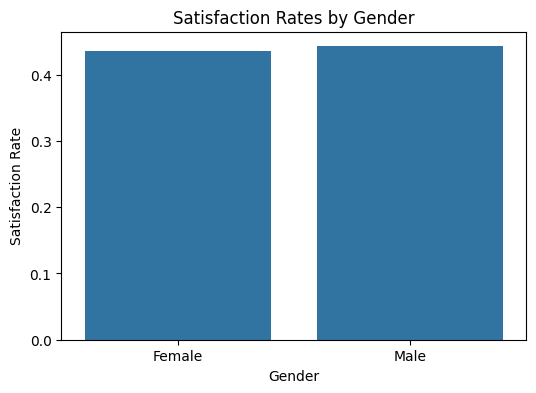

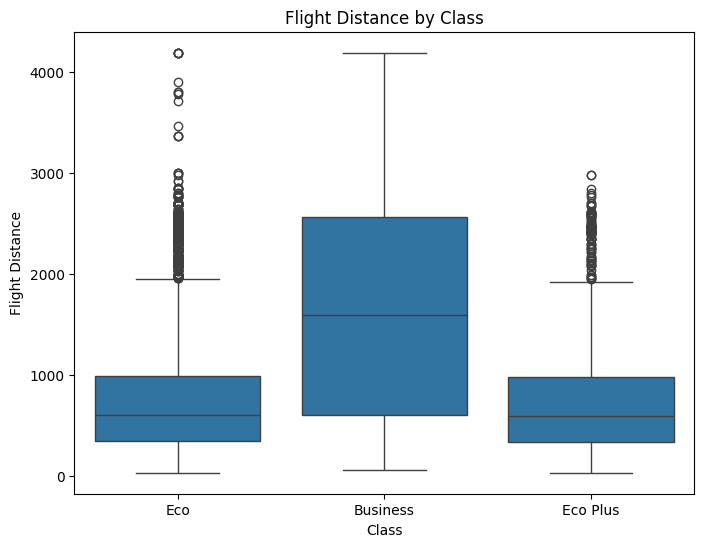

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql.functions import corr, mean
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix

# Convert results to DataFrame for visualization
results_df = pd.DataFrame(results)
print(results_df)

# General Model Performance Visualizations
# Visualize Accuracy Comparison
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.show()

# Visualize F1 Score Comparison
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='F1 Score', data=results_df)
plt.title('Model F1 Score Comparison')
plt.xticks(rotation=45)
plt.show()

# Model-Specific Visualizations for 7 Models
models_to_visualize = [
    'Logistic Regression', 'Decision Tree', 'Random Forest',
    'Gradient Boosted Trees', 'Naive Bayes', 'Multilayer Perceptron', 'Extra Trees'
]

# Filter models that have a 'probability' column
models_with_probs = [model_name for model_name in models_to_visualize if 'probability' in predictions[model_name].columns]

# Visualization 1: ROC Curves for Each Model with Probabilities
for model_name in models_with_probs:
    pred = predictions[model_name]
    # Extract probabilities and labels
    probs_and_labels = pred.select("probability", "satisfaction_binary").toPandas()
    y_true = probs_and_labels['satisfaction_binary']
    y_scores = probs_and_labels['probability'].apply(lambda x: x[1])  # Probability of positive class

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {model_name}')
    plt.legend()
    plt.show()

# Visualization 2: Precision-Recall Curves for Each Model with Probabilities
for model_name in models_with_probs:
    pred = predictions[model_name]
    # Extract probabilities and labels
    probs_and_labels = pred.select("probability", "satisfaction_binary").toPandas()
    y_true = probs_and_labels['satisfaction_binary']
    y_scores = probs_and_labels['probability'].apply(lambda x: x[1])  # Probability of positive class

    # Compute Precision-Recall curve and AP (Average Precision)
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    avg_precision = average_precision_score(y_true, y_scores)

    # Plot Precision-Recall curve
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='green', label=f'Precision-Recall Curve (AP = {avg_precision:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve for {model_name}')
    plt.legend()
    plt.show()

# Visualization 3: Confusion Matrices for Each Model
for model_name in models_to_visualize:
    pred = predictions[model_name]
    y_true = pred.select("satisfaction_binary").toPandas()
    y_pred = pred.select("prediction").toPandas()
    cm = confusion_matrix(y_true, y_pred)

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Dissatisfied', 'Satisfied'],
                yticklabels=['Dissatisfied', 'Satisfied'])
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Additional Visualizations
# Visualization 4: Feature Importance for Random Forest
feature_importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.featureImportances.toArray()
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importance (Random Forest)')
plt.show()

# Visualization 5: Correlation Heatmap of Numerical Features
num_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes',
            'Arrival Delay in Minutes', 'experience_score']
corr_matrix = pd.DataFrame(index=num_cols, columns=num_cols)
for col1 in num_cols:
    for col2 in num_cols:
        corr_val = final_df_indexed.select(corr(col1, col2).alias('corr')).collect()[0]['corr']
        corr_matrix.loc[col1, col2] = corr_val

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix.astype(float), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Visualization 6: Distribution of Age Before and After Outlier Handling
age_before = df.select('Age').toPandas()  # Original data
age_after = final_df_indexed.select('Age').toPandas()  # After winsorization in Operation 4

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(age_before['Age'], kde=True)
plt.title('Distribution of Age (Before Outlier Handling)')
plt.subplot(1, 2, 2)
sns.histplot(age_after['Age'], kde=True)
plt.title('Distribution of Age (After Outlier Handling)')
plt.tight_layout()
plt.show()

# Visualization 7: Satisfaction Rates by Gender
satisfaction_by_gender = final_df_indexed.groupBy('Gender') \
    .agg(mean('satisfaction_binary').alias('Satisfaction Rate')) \
    .toPandas()

plt.figure(figsize=(6, 4))
sns.barplot(x='Gender', y='Satisfaction Rate', data=satisfaction_by_gender)
plt.title('Satisfaction Rates by Gender')
plt.show()

# Visualization 8: Flight Distance by Class
flight_distance_by_class = final_df_indexed.select('Class', 'Flight Distance').toPandas()

plt.figure(figsize=(8, 6))
sns.boxplot(x='Class', y='Flight Distance', data=flight_distance_by_class)
plt.title('Flight Distance by Class')
plt.show()

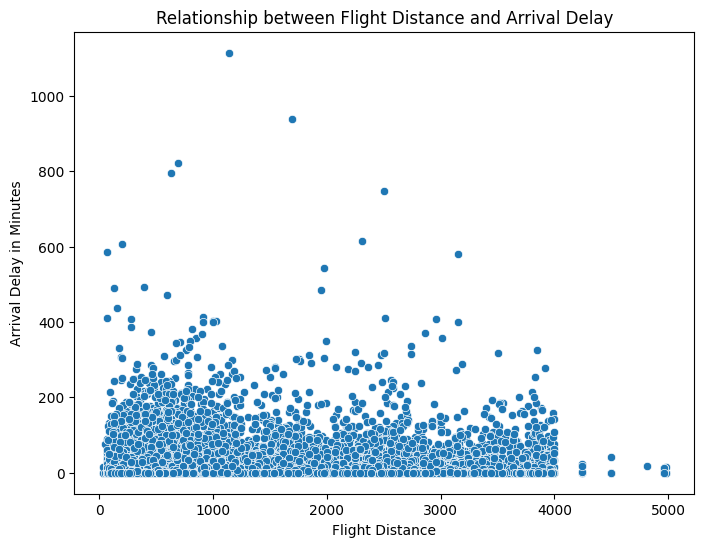

In [50]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Flight Distance', y='Arrival Delay in Minutes', data=df_clean.select('Flight Distance', 'Arrival Delay in Minutes').toPandas())
plt.title('Relationship between Flight Distance and Arrival Delay')
plt.xlabel('Flight Distance')
plt.ylabel('Arrival Delay in Minutes')
plt.show()

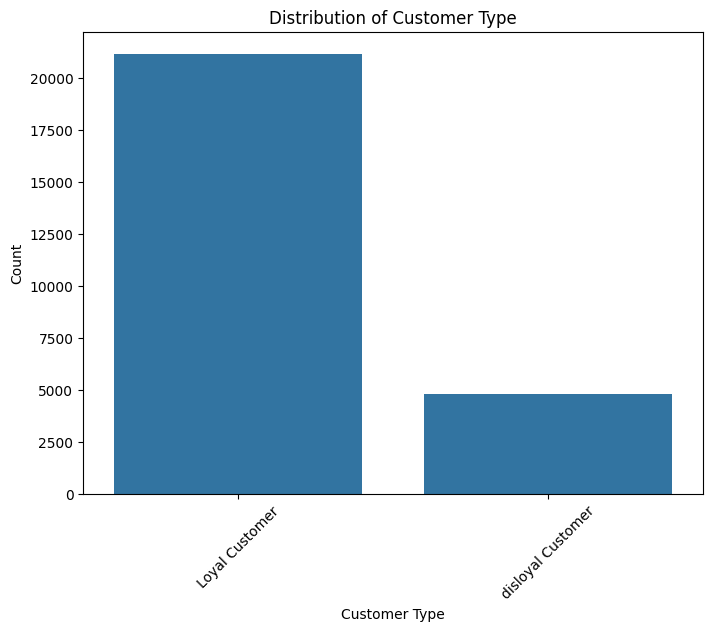

In [51]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Customer Type', data=df_clean.select('Customer Type').toPandas())
plt.title('Distribution of Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.show()

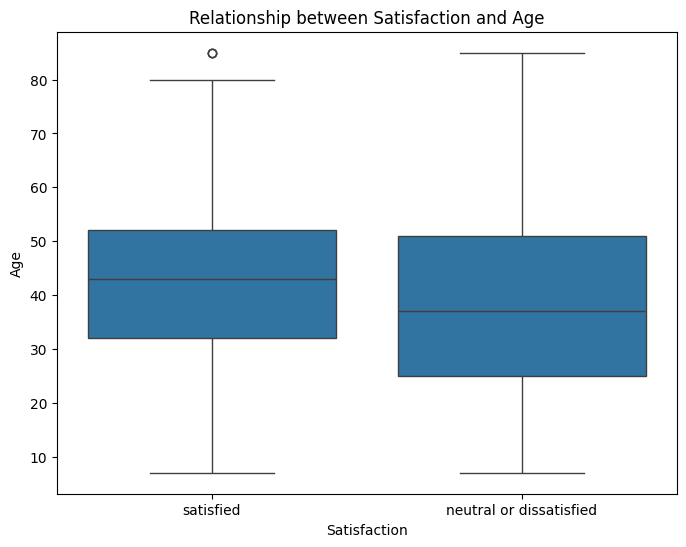

In [52]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='satisfaction', y='Age', data=df_clean.select('satisfaction', 'Age').toPandas())
plt.title('Relationship between Satisfaction and Age')
plt.xlabel('Satisfaction')
plt.ylabel('Age')
plt.show()

In [53]:
import plotly.express as px

In [54]:
fig = px.scatter(df_clean.select('Flight Distance', 'Arrival Delay in Minutes').toPandas(),
                 x='Flight Distance',
                 y='Arrival Delay in Minutes',
                 title='Relationship between Flight Distance and Arrival Delay',
                 labels={'Flight Distance': 'Flight Distance', 'Arrival Delay in Minutes': 'Arrival Delay'})
fig.show()

In [55]:
import plotly.graph_objects as go

# Assuming 'results_df' contains your model results
fig = go.Figure(data=[
    go.Bar(name='Accuracy', x=results_df['Model'], y=results_df['Accuracy']),
    go.Bar(name='F1 Score', x=results_df['Model'], y=results_df['F1 Score'])
])
fig.update_layout(barmode='group', title_text='Model Performance Comparison')
fig.show()

In [56]:
import plotly.graph_objects as go

# Assuming 'results' is a list of dictionaries with model names and metrics
for model_result in results:
    model_name = model_result['Model']
    accuracy = model_result['Accuracy']  # Accessing accuracy from dictionary

    fig = go.Figure(data=[go.Bar(x=[model_name], y=[accuracy])])
    fig.update_layout(title_text=f"{model_name} Accuracy: {accuracy:.2f}")
    fig.show()

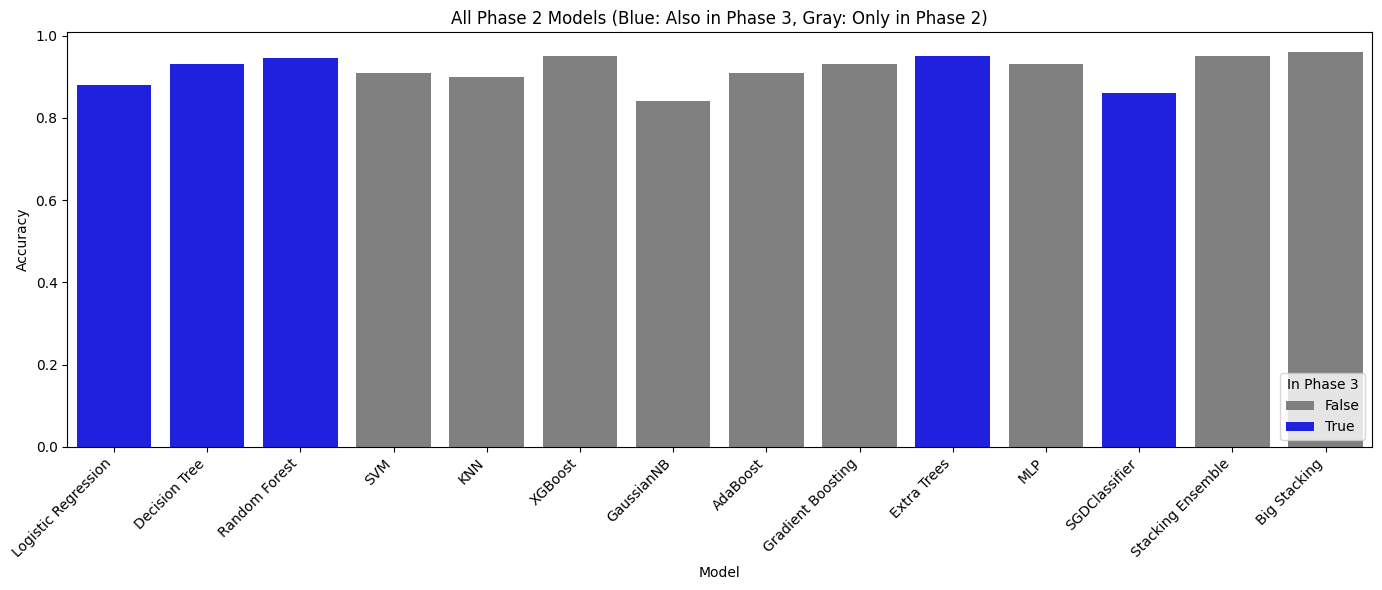

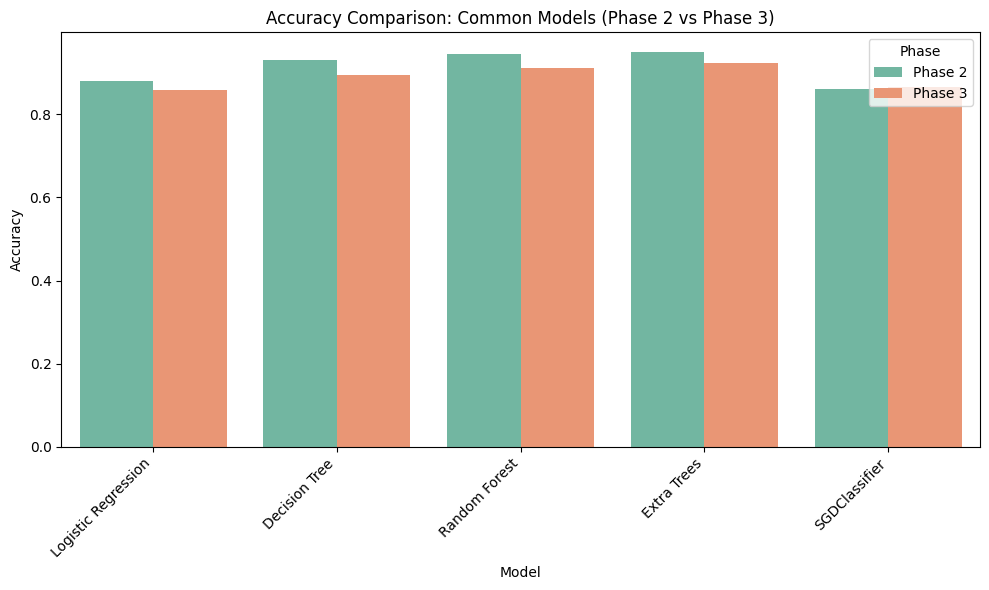

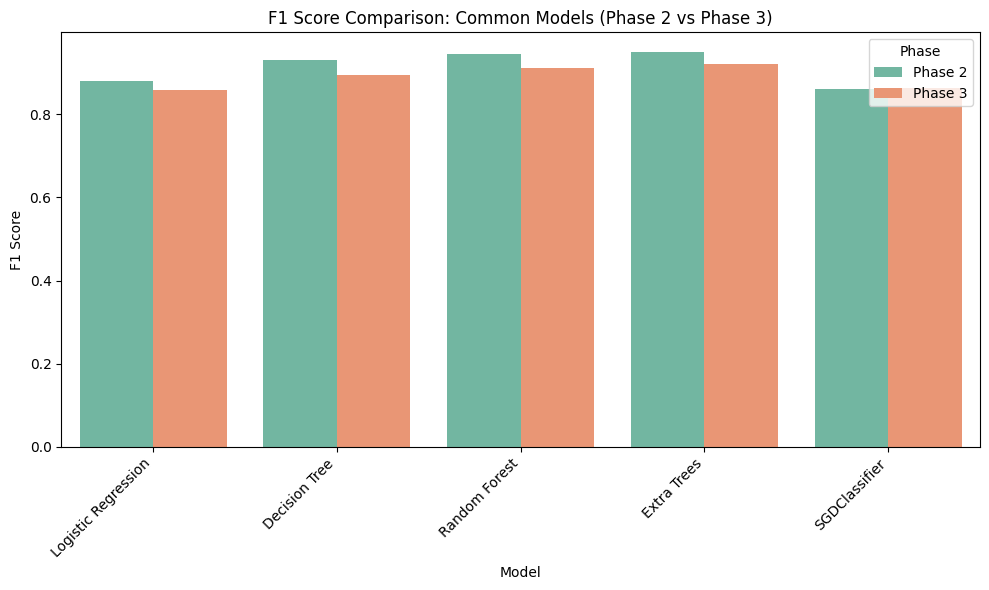

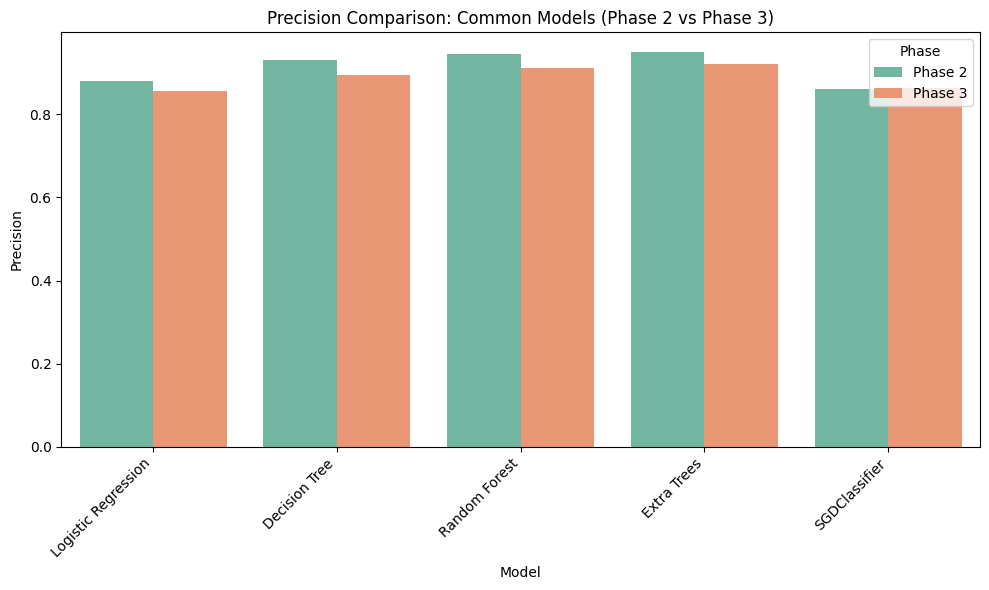

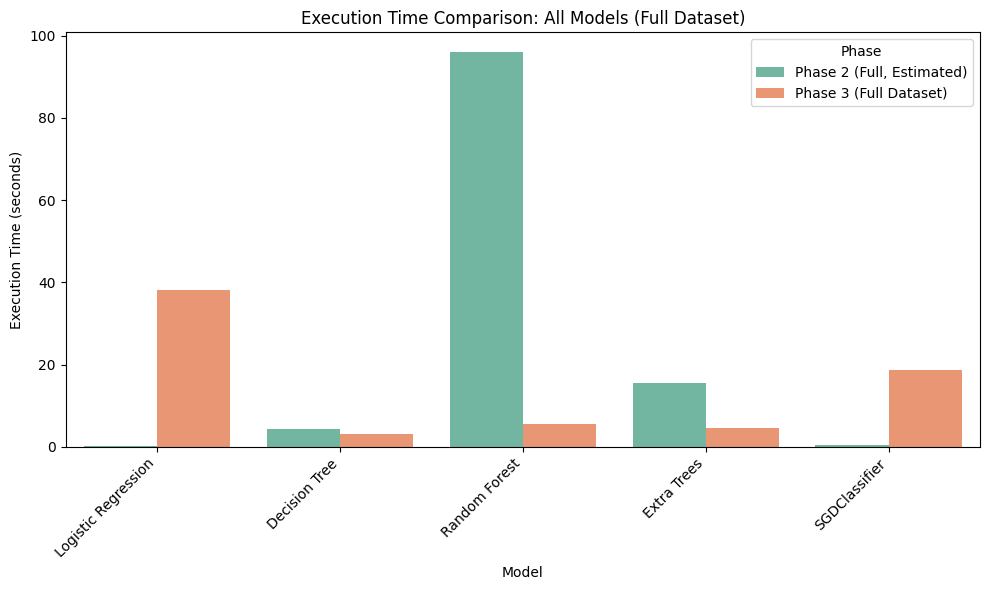

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Plot 1: All Phase 2 Models with Highlighted Common Models (Accuracy)
phase2_models = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Accuracy': 0.88, 'In_Phase3': True},
    {'Model': 'Decision Tree', 'Accuracy': 0.93, 'In_Phase3': True},
    {'Model': 'Random Forest', 'Accuracy': 0.945, 'In_Phase3': True},
    {'Model': 'SVM', 'Accuracy': 0.91, 'In_Phase3': False},
    {'Model': 'KNN', 'Accuracy': 0.90, 'In_Phase3': False},
    {'Model': 'XGBoost', 'Accuracy': 0.95, 'In_Phase3': False},
    {'Model': 'GaussianNB', 'Accuracy': 0.84, 'In_Phase3': False},
    {'Model': 'AdaBoost', 'Accuracy': 0.91, 'In_Phase3': False},
    {'Model': 'Gradient Boosting', 'Accuracy': 0.93, 'In_Phase3': False},
    {'Model': 'Extra Trees', 'Accuracy': 0.95, 'In_Phase3': True},
    {'Model': 'MLP', 'Accuracy': 0.93, 'In_Phase3': False},
    {'Model': 'SGDClassifier', 'Accuracy': 0.86, 'In_Phase3': True},
    {'Model': 'Stacking Ensemble', 'Accuracy': 0.95, 'In_Phase3': False},
    {'Model': 'Big Stacking', 'Accuracy': 0.96, 'In_Phase3': False}
])

plt.figure(figsize=(14, 6))
sns.barplot(x='Model', y='Accuracy', hue='In_Phase3', dodge=False, data=phase2_models, palette={True: 'blue', False: 'gray'})
plt.title('All Phase 2 Models (Blue: Also in Phase 3, Gray: Only in Phase 2)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.legend(title='In Phase 3', loc='lower right')
plt.tight_layout()
plt.show()

# Plot 2: Accuracy Comparison of Common Models (Phase 2 vs Phase 3)
comparison_accuracy_df = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Phase': 'Phase 2', 'Accuracy': 0.880},
    {'Model': 'Logistic Regression', 'Phase': 'Phase 3', 'Accuracy': 0.858369},
    {'Model': 'Decision Tree', 'Phase': 'Phase 2', 'Accuracy': 0.930},
    {'Model': 'Decision Tree', 'Phase': 'Phase 3', 'Accuracy': 0.894850},
    {'Model': 'Random Forest', 'Phase': 'Phase 2', 'Accuracy': 0.945},
    {'Model': 'Random Forest', 'Phase': 'Phase 3', 'Accuracy': 0.912017},
    {'Model': 'Extra Trees', 'Phase': 'Phase 2', 'Accuracy': 0.950},
    {'Model': 'Extra Trees', 'Phase': 'Phase 3', 'Accuracy': 0.922747},
    {'Model': 'SGDClassifier', 'Phase': 'Phase 2', 'Accuracy': 0.860},
    {'Model': 'SGDClassifier', 'Phase': 'Phase 3', 'Accuracy': 0.864807}
])

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', hue='Phase', data=comparison_accuracy_df, palette='Set2')
plt.title('Accuracy Comparison: Common Models (Phase 2 vs Phase 3)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.legend(title='Phase')
plt.tight_layout()
plt.show()

# Plot 3: F1 Score Comparison of Common Models (Phase 2 vs Phase 3)
comparison_f1_df = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Phase': 'Phase 2', 'F1 Score': 0.880},
    {'Model': 'Logistic Regression', 'Phase': 'Phase 3', 'F1 Score': 0.857509},
    {'Model': 'Decision Tree', 'Phase': 'Phase 2', 'F1 Score': 0.930},
    {'Model': 'Decision Tree', 'Phase': 'Phase 3', 'F1 Score': 0.894351},
    {'Model': 'Random Forest', 'Phase': 'Phase 2', 'F1 Score': 0.945},
    {'Model': 'Random Forest', 'Phase': 'Phase 3', 'F1 Score': 0.911442},
    {'Model': 'Extra Trees', 'Phase': 'Phase 2', 'F1 Score': 0.950},
    {'Model': 'Extra Trees', 'Phase': 'Phase 3', 'F1 Score': 0.922477},
    {'Model': 'SGDClassifier', 'Phase': 'Phase 2', 'F1 Score': 0.860},
    {'Model': 'SGDClassifier', 'Phase': 'Phase 3', 'F1 Score': 0.863516}
])

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='F1 Score', hue='Phase', data=comparison_f1_df, palette='Set2')
plt.title('F1 Score Comparison: Common Models (Phase 2 vs Phase 3)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('F1 Score')
plt.legend(title='Phase')
plt.tight_layout()
plt.show()

# Plot 4: Precision Comparison of Common Models (Phase 2 vs Phase 3)
comparison_precision_df = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Phase': 'Phase 2', 'Precision': 0.880},
    {'Model': 'Logistic Regression', 'Phase': 'Phase 3', 'Precision': 0.857500},
    {'Model': 'Decision Tree', 'Phase': 'Phase 2', 'Precision': 0.930},
    {'Model': 'Decision Tree', 'Phase': 'Phase 3', 'Precision': 0.894300},
    {'Model': 'Random Forest', 'Phase': 'Phase 2', 'Precision': 0.945},
    {'Model': 'Random Forest', 'Phase': 'Phase 3', 'Precision': 0.911400},
    {'Model': 'Extra Trees', 'Phase': 'Phase 2', 'Precision': 0.950},
    {'Model': 'Extra Trees', 'Phase': 'Phase 3', 'Precision': 0.922200},
    {'Model': 'SGDClassifier', 'Phase': 'Phase 2', 'Precision': 0.860},
    {'Model': 'SGDClassifier', 'Phase': 'Phase 3', 'Precision': 0.863500}
])

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Precision', hue='Phase', data=comparison_precision_df, palette='Set2')
plt.title('Precision Comparison: Common Models (Phase 2 vs Phase 3)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Precision')
plt.legend(title='Phase')
plt.tight_layout()
plt.show()

# Plot: Normalized Execution Time per Row (Full Dataset)
# Plot: Execution Time Comparison (All Models: Full Dataset)
all_models_time_df = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Phase': 'Phase 2 (Full, Estimated)', 'Execution Time': 0.10},
    {'Model': 'Logistic Regression', 'Phase': 'Phase 3 (Full Dataset)', 'Execution Time': 38.04},
    {'Model': 'Decision Tree', 'Phase': 'Phase 2 (Full, Estimated)', 'Execution Time': 4.40},
    {'Model': 'Decision Tree', 'Phase': 'Phase 3 (Full Dataset)', 'Execution Time': 3.12},
    {'Model': 'Random Forest', 'Phase': 'Phase 2 (Full, Estimated)', 'Execution Time': 96.00},
    {'Model': 'Random Forest', 'Phase': 'Phase 3 (Full Dataset)', 'Execution Time': 5.43},
    {'Model': 'Extra Trees', 'Phase': 'Phase 2 (Full, Estimated)', 'Execution Time': 15.60},
    {'Model': 'Extra Trees', 'Phase': 'Phase 3 (Full Dataset)', 'Execution Time': 4.45},
    {'Model': 'SGDClassifier', 'Phase': 'Phase 2 (Full, Estimated)', 'Execution Time': 0.50},
    {'Model': 'SGDClassifier', 'Phase': 'Phase 3 (Full Dataset)', 'Execution Time': 18.66}
])

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Execution Time', hue='Phase', data=all_models_time_df, palette='Set2')
plt.title('Execution Time Comparison: All Models (Full Dataset)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Execution Time (seconds)')
plt.legend(title='Phase')
plt.tight_layout()
plt.show()

DAG Explanation for Logistic Regression:
Logistic Regression does not support explain() in this Spark version.
DAG Explanation for Random Forest:
Random Forest does not support explain() in this Spark version.
DAG Explanation for Multilayer Perceptron:
Multilayer Perceptron does not support explain() in this Spark version.
Phase 3 vs Phase 2 Comparison:
                    Model  Accuracy_Phase3  Accuracy_Phase2
0     Logistic Regression         0.866718            0.880
1           Decision Tree         0.902542            0.930
2           Random Forest         0.919299            0.945
3  Gradient Boosted Trees         0.937789              NaN
4              Linear SVC         0.868259              NaN
5             Naive Bayes         0.811441              NaN
6   Multilayer Perceptron         0.796995              NaN
7             Extra Trees         0.917951            0.950
8           SGDClassifier         0.868259            0.850


<Figure size 1200x600 with 0 Axes>

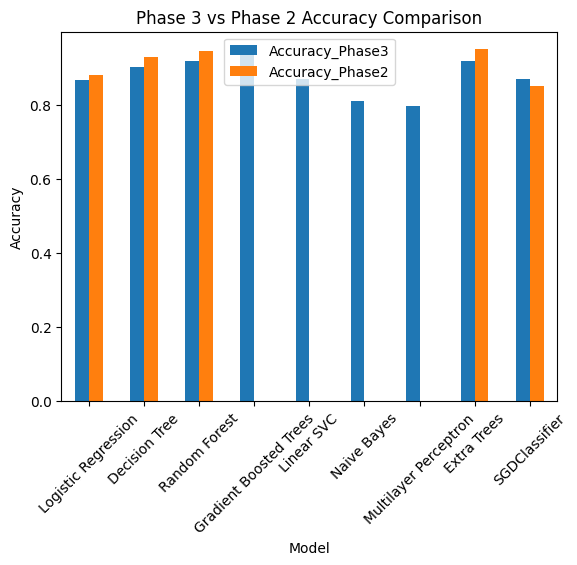

In [59]:
# Deliverable 3: Explanation and Analysis

# Function to print DAG explanation
def print_dag_explanation(model_name, model):
    print(f"DAG Explanation for {model_name}:")
    try:
        print(model.explain())
    except AttributeError:
        print(f"{model_name} does not support explain() in this Spark version.")

# Print DAG for key models
print_dag_explanation("Logistic Regression", lr_model)
print_dag_explanation("Random Forest", rf_model)
print_dag_explanation("Multilayer Perceptron", mlp_model)

# Comparative analysis with Phase 2
phase2_results = [
    {'Model': 'Logistic Regression', 'Accuracy': 0.88},
    {'Model': 'Decision Tree', 'Accuracy': 0.93},
    {'Model': 'Random Forest', 'Accuracy': 0.945},
    {'Model': 'SVM', 'Accuracy': 0.91},
    {'Model': 'KNN', 'Accuracy': 0.90},
    {'Model': 'XGBoost', 'Accuracy': 0.95},
    {'Model': 'GaussianNB', 'Accuracy': 0.84},
    {'Model': 'AdaBoost', 'Accuracy': 0.91},
    {'Model': 'Gradient Boosting', 'Accuracy': 0.93},
    {'Model': 'Extra Trees', 'Accuracy': 0.95},
    {'Model': 'MLP', 'Accuracy': 0.93},
    {'Model': 'SGDClassifier', 'Accuracy': 0.85},
    {'Model': 'Stacking Ensemble', 'Accuracy': 0.95},
    {'Model': 'Big Stacking', 'Accuracy': 0.96}
]

phase2_df = pd.DataFrame(phase2_results)
comparison_df = results_df[['Model', 'Accuracy']].merge(
    phase2_df[['Model', 'Accuracy']],
    on='Model',
    suffixes=('_Phase3', '_Phase2'),
    how='left'
)

print("Phase 3 vs Phase 2 Comparison:")
print(comparison_df)

# Visualize comparison
plt.figure(figsize=(12, 6))
comparison_df.set_index('Model')[['Accuracy_Phase3', 'Accuracy_Phase2']].plot(kind='bar')
plt.title('Phase 3 vs Phase 2 Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()

In [22]:
!pip install pyngrok

from pyngrok import ngrok


In [24]:
!ngrok config add-authtoken 2vgn8nM7J9IYiC8p5HQsSgQP9DW_3PfgmiE9m69rEJauim12x


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [25]:
from pyngrok import ngrok
public_url = ngrok.connect(4040)
print("Spark UI is available at:", public_url)


Spark UI is available at: NgrokTunnel: "https://8d1e-34-86-60-150.ngrok-free.app" -> "http://localhost:4040"
